In [5]:
import numpy as np
import pandas as pd
import fastf1 as ff1


ff1.Cache.enable_cache('./cache')
ff1.set_log_level('ERROR')
ff1.Cache.offline_mode(True)

# DATA PREPROCESSING

### PREPARE THE DATA

In [47]:
import os

data_dir = './f1_data'
race_file = os.path.join(data_dir, 'f1_strategy_NN_19_25.csv')

df_race = pd.read_csv(race_file)

In [48]:
def check_dataset_integrity(df):
    """
    Checks for missing values and provides a summary of the dataset health.
    """
    print("--- Dataset Integrity Check ---")
    
    # 1. Count nulls per column
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100
    
    # 2. Filter only columns with nulls
    missing_data = pd.concat([null_counts, null_percentages], axis=1, keys=['Total Nulls', 'Percentage'])
    missing_data = missing_data[missing_data['Total Nulls'] > 0]
    
    if missing_data.empty:
        print("✅ No missing values found! The dataset is clean.")
    else:
        print("⚠️ Missing values detected:")
        print(missing_data)
            
    return missing_data


In [49]:
import os

data_dir = './f1_data'
constructor_file = os.path.join(data_dir, 'f1_constructor_results.csv')
circuit_file = os.path.join(data_dir, 'f1_circuits_clustered.csv')

df_constructor = pd.read_csv(constructor_file)
df_circuits = pd.read_csv(circuit_file)

# ---------------------------------------------------------
# 1. FIX GRAND PRIX NAMES (Excluding Sakhir)
# ---------------------------------------------------------
gp_mapping = {
    'Brazilian Grand Prix': 'São Paulo Grand Prix',
    'Mexican Grand Prix': 'Mexico City Grand Prix',
    '70th Anniversary Grand Prix': 'British Grand Prix',
    'Styrian Grand Prix': 'Austrian Grand Prix'
    # Sakhir is intentionally ignored; it will remain NaN and be dropped later
}

# Rename the GPs in the main dataframe
df_race['GP'] = df_race['GP'].replace(gp_mapping)

# Create a dictionary from df_circuits to map the correct Track_Archetype
track_dict = dict(zip(df_circuits['EventName'], df_circuits['Track_Archetype']))

# Overwrite the TrackType column using the updated GP names
df_race['TrackType'] = df_race['GP'].map(track_dict)

# ---------------------------------------------------------
# 2. FIX TEAMS (Using the updated df_constructor)
# ---------------------------------------------------------
# Drop the old column with null values if it exists
if 'ConstructorChampionshipPosition' in df_race.columns:
    df_race.drop(columns=['ConstructorChampionshipPosition'], inplace=True)

# Prepare the updated constructor data
constructor_data = df_constructor[['Year', 'Team', 'Position']].rename(
    columns={'Position': 'ConstructorChampionshipPosition'}
)

# Perform a new left merge to attach the correct championship positions
df_race = pd.merge(df_race, constructor_data, on=['Year', 'Team'], how='left')

# Normalize the values between 0.0 and 1.0
max_position = df_race['ConstructorChampionshipPosition'].max()
if pd.notna(max_position) and max_position > 0:
    df_race['ConstructorChampionshipPosition'] = df_race['ConstructorChampionshipPosition'] / max_position

In [50]:
# ---------------------------------------------------------
# 3. FINAL CLEANUP (Drop remaining NaNs)
# ---------------------------------------------------------
# Drop the laps missing the Compound data
df_race.dropna(subset=['Compound'], inplace=True)

# Drop the races that don't have a TrackType (Sakhir, Russia, Mugello, etc.)
df_race.dropna(subset=['TrackType'], inplace=True)

# Drop any remaining rows where the constructor couldn't be mapped
df_race.dropna(subset=['ConstructorChampionshipPosition'], inplace=True)

# Drop rows where 'Position' is missing (crucial feature for M10 model)
df_race.dropna(subset=['Position'], inplace=True)

# Drop rows where 'LapTime' is missing
df_race.dropna(subset=['LapTime'], inplace=True)

# Drop all rows where the 'Compound' is exactly 'UNKNOWN'
df_race.drop(df_race[df_race['Compound'] == 'UNKNOWN'].index, inplace=True)

print("✅ Dataframe successfully repaired and cleaned!")
print(f"Final number of rows: {len(df_race)}")

✅ Dataframe successfully repaired and cleaned!
Final number of rows: 111815


In [51]:
# ---------------------------------------------------------
# 1. CLEAN AND SIMPLIFY TRACKSTATUS
# ---------------------------------------------------------
# Convert floats (like 1267.0) to integers, then to strings ("1267")
df_race['TrackStatus_Str'] = df_race['TrackStatus'].astype(int).astype(str)

def get_worst_status(status_str):
    """
    Extracts the most severe track condition from the FastF1 status sequence.
    Priority: Red Flag (5) > Safety Car (4) > VSC (6) > Yellow Flag (2) > Green (1)
    """
    if '5' in status_str:
        return 'RedFlag'
    elif '4' in status_str:
        return 'SafetyCar'
    elif '6' in status_str:
        return 'VSC'
    elif '2' in status_str:
        return 'YellowFlag'
    else:
        return 'GreenFlag'

# Apply the function to create a clean categorical column
df_race['CleanTrackStatus'] = df_race['TrackStatus_Str'].apply(get_worst_status)


In [41]:
check_dataset_integrity(df_race)

--- Dataset Integrity Check ---
⚠️ Missing values detected:
                    Total Nulls  Percentage
PitOutTime               108855   97.352770
PitInTime                108598   97.122926
Sector1Time                1923    1.719805
Sector2Time                  44    0.039351
Sector3Time                  48    0.042928
Sector1SessionTime         2198    1.965747
Sector2SessionTime           44    0.039351
Sector3SessionTime           48    0.042928
SpeedI1                       1    0.000894
SpeedI2                     885    0.791486
SpeedFL                    3217    2.877074
SpeedST                      10    0.008943
GapToCarAhead              6118    5.471538
GapToCarBehind             6142    5.493002


,Total Nulls,Percentage
PitOutTime,108855,97.352770
PitInTime,108598,97.122926
Sector1Time,1923,1.719805
Sector2Time,44,0.039351
Sector3Time,48,0.042928
Sector1SessionTime,2198,1.965747
Sector2SessionTime,44,0.039351
Sector3SessionTime,48,0.042928
SpeedI1,1,0.000894
SpeedI2,885,0.791486


In [52]:
import pandas as pd
import numpy as np

# Assuming df_race is your current dataframe right before one-hot encoding

# ---------------------------------------------------------
# 1. CALCULATE THE XGBOOST TARGET (LapDeltaSeconds)
# ---------------------------------------------------------
# We use ONLY clean laps to establish the mathematically correct baseline
clean_laps_mask = (
    (df_race['LapNumber'] > 1) & 
    (df_race['InPits'] == False) & 
    (df_race['TrackStatus'] == 1.0) # Assuming 1.0 is Green Flag
)

clean_laps = df_race[clean_laps_mask]

# Calculate the 5th percentile (Robust Fastest Lap)
baseline_pace = clean_laps.groupby(['Year', 'GP'])['LapTime_ms'].quantile(0.05).reset_index()
baseline_pace.rename(columns={'LapTime_ms': 'Baseline_LapTime_ms'}, inplace=True)

# Merge back to the ENTIRE dataset (df_race). 
# We calculate Delta for all laps, even Safety Cars. NN will see these huge deltas, 
# but it also knows TrackStatus, so it won't get confused.
df_race = pd.merge(df_race, baseline_pace, on=['Year', 'GP'], how='left')
df_race['LapDeltaSeconds'] = (df_race['LapTime_ms'] - df_race['Baseline_LapTime_ms']) / 1000.0

# ---------------------------------------------------------
# 1. CREATE POLYNOMIAL FEATURE (Tyre drop-off)
# ---------------------------------------------------------
# We square the tyre life progress. 
# This helps XGBoost understand that tyre degradation is not a straight line,
# but a curve that drops off sharply towards the end of the stint.
df_race['TyreLifeProgress_Squared'] = df_race['TyreLifeProgress'] ** 2

In [53]:
# ---------------------------------------------------------
# 2. DROP COLUMNS USELESS TO BOTH MODELS
# ---------------------------------------------------------
# Drop the baseline to avoid data leakage for XGBoost.
# Drop raw time columns that we don't need anymore.
cols_to_drop = ['Baseline_LapTime_ms', 'LapTime', 'LapTime_ms'] 
df_race.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Drop the old raw columns to prevent data duplication
df_race.drop(columns=['TrackStatus', 'TrackStatus_Str'], inplace=True)

cols_to_drop = [
    'Sector1Time', 'Sector2Time', 'Sector3Time', 
    'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
    'Time', 'Stint', 'PitOutTime', 'PitInTime',
    'TyreLife', 'FreshTyre', 'Deleted', 'IsAccurate', 
    'GapToCarAhead', 'GapToCarBehind', 'RealTrackPosition',
]
df_race.drop(columns=cols_to_drop, errors='ignore', inplace=True)

In [54]:
# ---------------------------------------------------------
# 2. ONE-HOT ENCODING (Compound & TrackStatus)
# ---------------------------------------------------------
# Create dummy variables (1 or 0) for each category
df_race = pd.get_dummies(df_race, columns=['Compound', 'CleanTrackStatus', 'Driver'], drop_first=False)

# In newer Pandas versions, get_dummies returns booleans (True/False). 
# We need to explicitly convert them to integers (1/0) for TensorFlow.
dummy_cols = [col for col in df_race.columns if 'Compound_' in col or 'CleanTrackStatus_' in col]
for col in dummy_cols:
    df_race[col] = df_race[col].astype(int)

# ---------------------------------------------------------
# 3. CONVERT BOOLEAN FLAGS TO 1/0
# ---------------------------------------------------------
# Neural networks require numeric inputs, so we map True->1 and False->0
bool_columns = ['InPits', 'CarClose', 'PitStopBehind', 'TwoTyreCompoundsUsed']

for col in bool_columns:
    if col in df_race.columns:
        df_race[col] = df_race[col].astype(int)

# Convert boolean values (True/False) to integers (1/0) for XGBoost
encoded_cols = [col for col in df_race.columns if 'Driver_' in col or 'Compound_' in col]
for col in encoded_cols:
    df_race[col] = df_race[col].astype(int)

print("✅ Encoding complete! The dataframe is strictly numeric now.")
print("New columns generated:", dummy_cols)

✅ Encoding complete! The dataframe is strictly numeric now.
New columns generated: ['Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 'CleanTrackStatus_GreenFlag', 'CleanTrackStatus_RedFlag', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 'CleanTrackStatus_YellowFlag']


### SAVE DATA

In [56]:
encoded_file = os.path.join(data_dir, 'f1_strategy_NN_XGB_19_25_encoded.csv')
df_race.to_csv(encoded_file, index=False)

print(f"✅ Saved encoded dataset to: {encoded_file}")

✅ Saved encoded dataset to: ./f1_data\f1_strategy_NN_XGB_19_25_encoded.csv


# TRAINING

In [6]:
import os

data_dir = './f1_data'
race_file = os.path.join(data_dir, 'f1_strategy_NN_XGB_19_25_encoded.csv')
df_race = pd.read_csv(race_file)

## NEURAL NETWORK

### TRAIN TEST SPLIT

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------------------------------------
# 1. SPLIT DATA (Train, Validation, Test)
# ---------------------------------------------------------
# We use the most recent year in your dataset as the unseen Test Set (e.g., 2024 or 2025)
test_year = df_race['Year'].max()

# Create masks to separate the data
train_val_mask = df_race['Year'] < test_year
test_mask = df_race['Year'] == test_year

df_train_val_nn = df_race[train_val_mask].copy()
df_test_nn = df_race[test_mask].copy()

# Features for the neural network
nn_cols_to_keep = [
    'Position', 
    'TrackTemp', 
    'RaceProgress', 
    'TyreLifeProgress', 
    'CarClose', 
    'PitStopBehind', 
    'TwoTyreCompoundsUsed', 
    'TrackType', 
    'ConstructorChampionshipPosition', 
    'Compound_HARD', 
    'Compound_MEDIUM', 
    'Compound_SOFT', 
    'CleanTrackStatus_GreenFlag', 
    'CleanTrackStatus_RedFlag', 
    'CleanTrackStatus_SafetyCar', 
    'CleanTrackStatus_VSC', 
    'CleanTrackStatus_YellowFlag'
]

X_train_val_nn = df_train_val_nn[nn_cols_to_keep]
y_train_val_nn = df_train_val_nn['InPits']

X_test_nn = df_test_nn[nn_cols_to_keep]
y_test_nn = df_test_nn['InPits']

# Split the historical data into Train (80%) and Validation (20%)
# stratify=y_train_val ensures both sets have the same ~3% ratio of pit stops
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train_val_nn, y_train_val_nn,
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_val_nn
)

print(f"Features ready for the Neural Network: {X_train_nn.shape[1]}")
print(f"Train samples: {X_train_nn.shape[0]} | Validation samples: {X_valid_nn.shape[0]} | Test samples: {X_test_nn.shape[0]}")

Features ready for the Neural Network: 17
Train samples: 75192 | Validation samples: 18799 | Test samples: 17824


In [62]:
X_train_nn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75192 entries, 61105 to 41097
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Position                         75192 non-null  float64
 1   TrackTemp                        75192 non-null  float64
 2   RaceProgress                     75192 non-null  float64
 3   TyreLifeProgress                 75192 non-null  float64
 4   CarClose                         75192 non-null  int64  
 5   PitStopBehind                    75192 non-null  int64  
 6   TwoTyreCompoundsUsed             75192 non-null  int64  
 7   TrackType                        75192 non-null  float64
 8   ConstructorChampionshipPosition  75192 non-null  float64
 9   Compound_HARD                    75192 non-null  int64  
 10  Compound_MEDIUM                  75192 non-null  int64  
 11  Compound_SOFT                    75192 non-null  int64  
 12  CleanTrackStatus_Gr

### TRAINING NN

In [72]:
# ---------------------------------------------------------
# BUILD THE NEURAL NETWORK (M10 Architecture)
# ---------------------------------------------------------
# We use a Sequential model with Dense layers (Standard Feed-Forward Neural Network)
model = Sequential([
    # First Hidden Layer + Input Shape specification
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.2), # Randomly drops 20% of neurons to prevent overfitting
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Third Hidden Layer
    Dense(16, activation='relu'),
    
    # Output Layer: 1 single neuron with Sigmoid activation
    # Sigmoid squashes the output between 0.0 and 1.0 (Probability of a Pit Stop)
    Dense(1, activation='sigmoid')
])

# ---------------------------------------------------------
# COMPILE THE MODEL
# ---------------------------------------------------------
# We use Binary Crossentropy for 1/0 classification.
# IMPORTANT: We add AUC, Precision, and Recall because 'accuracy' is misleading 
# when 97% of the laps are not pit stops!
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Display the network architecture
model.summary()

c:\Users\lucam\anaconda3\envs\myenv_310_f1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# 1. CALCULATE CLASS WEIGHTS (Addressing Imbalance)
# ---------------------------------------------------------
# Calculate weights to penalize the model heavily if it misses a pit stop (Class 1)
weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_nn),
    y=y_train_nn
)

# Convert to a dictionary for TensorFlow Keras
weights_dict = {0: weights_array[0], 1: weights_array[1]}
print(f"Class Weights applied: {weights_dict}")
# You will see that class 1 (Pit Stop) gets a much higher weight than class 0!

# ---------------------------------------------------------
# 2. EARLY STOPPING CALLBACK
# ---------------------------------------------------------
# Stop training if 'val_loss' doesn't improve for 10 epochs.
# restore_best_weights=True ensures we keep the most optimized version of the model.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# ---------------------------------------------------------
# 3. TRAIN THE NEURAL NETWORK
# ---------------------------------------------------------
print("\n🟢 Starting Model Training (Grab a coffee, this might take a minute!)...")
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_valid_nn, y_valid_nn),
    epochs=100,            # Maximum loops over the dataset
    batch_size=64,         # Number of rows processed at once
    class_weight=weights_dict, 
    callbacks=[early_stop],
    verbose=1              # Shows the progress bar
)

# ---------------------------------------------------------
# 4. EVALUATE ON UNSEEN TEST DATA
# ---------------------------------------------------------
print("\n🏁 Evaluating the model on the unseen Test Set...")
test_results = model.evaluate(X_test_nn, y_test_nn, verbose=0)

# Extract metrics based on the compiled model
print("\n--- FINAL TEST RESULTS ---")
print(f"Loss:      {test_results[0]:.4f}")
print(f"Accuracy:  {test_results[1]:.4f}")
print(f"AUC:       {test_results[2]:.4f} (Higher is better, 0.5 is random guess)")
print(f"Precision: {test_results[3]:.4f} (When it predicts a pit stop, how often is it right?)")
print(f"Recall:    {test_results[4]:.4f} (Out of all real pit stops, how many did it catch?)")

Class Weights applied: {0: np.float64(0.5149078956378826), 1: np.float64(17.26963711529628)}

🟢 Starting Model Training (Grab a coffee, this might take a minute!)...
Epoch 1/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7223 - auc: 0.8362 - loss: 0.4988 - precision: 0.0774 - recall: 0.7873 - val_accuracy: 0.7226 - val_auc: 0.8423 - val_loss: 0.4953 - val_precision: 0.0777 - val_recall: 0.7904
Epoch 2/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7374 - auc: 0.8404 - loss: 0.4939 - precision: 0.0810 - recall: 0.7804 - val_accuracy: 0.7737 - val_auc: 0.8461 - val_loss: 0.4383 - val_precision: 0.0878 - val_recall: 0.7261
Epoch 3/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7385 - auc: 0.8410 - loss: 0.4929 - precision: 0.0810 - recall: 0.7763 - val_accuracy: 0.7222 - val_auc: 0.8459 - val_loss: 0.4965 - val_precision: 0.0780 - val_recall: 0.7941
Epoch 4/100
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7474 - auc: 0.8418 - loss: 0.4

### SAVE THE MODEL

In [76]:
# ---------------------------------------------------------
# 1. SAVE THE TRAINED MODEL
# ---------------------------------------------------------
# Save the entire model to a single file. 
# The '.keras' extension is the modern standard for TensorFlow 2.x
model_filename = 'f1_strategic_model_m10_v3.keras'
model.save(model_filename)
print(f"✅ Model successfully saved as '{model_filename}'!")
print("Next time, you can just use: model = tf.keras.models.load_model('f1_strategic_model_m10_v3.keras')\n")

✅ Model successfully saved as 'f1_strategic_model_m10_v3.keras'!
Next time, you can just use: model = tf.keras.models.load_model('f1_strategic_model_m10_v3.keras')



### PLOTTING

Calculating Feature Importance via Permutation (this might take a minute)...
Baseline Test AUC: 0.8685


C:\Users\lucam\AppData\Local\Temp\ipykernel_23044\3242305432.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


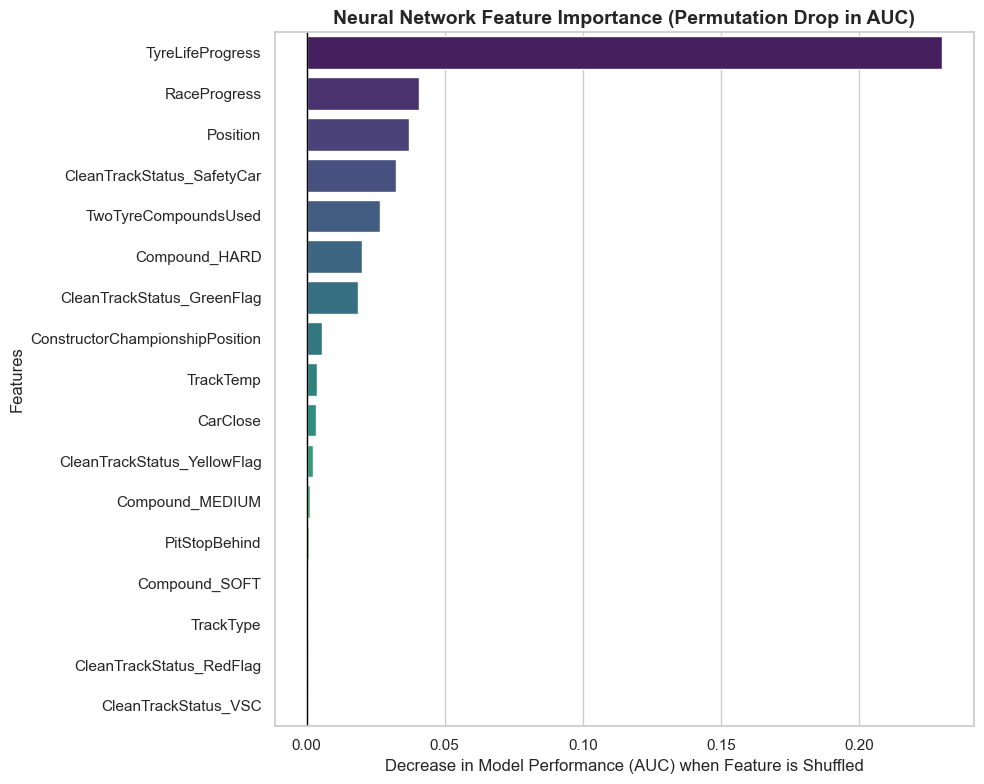


Top 5 Most Important Features:


,Feature,Importance_Score
0,TyreLifeProgress,0.230112
1,RaceProgress,0.040769
2,Position,0.037143
3,CleanTrackStatus_SafetyCar,0.032483
4,TwoTyreCompoundsUsed,0.026623


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

print("Calculating Feature Importance via Permutation (this might take a minute)...")

# ---------------------------------------------------------
# 1. CALCULATE BASELINE PERFORMANCE
# ---------------------------------------------------------
# We use AUC as our metric because it handles imbalanced data (97% vs 3%) very well
baseline_predictions = model.predict(X_test_nn, verbose=0)
baseline_auc = roc_auc_score(y_test_nn, baseline_predictions)
print(f"Baseline Test AUC: {baseline_auc:.4f}")

# ---------------------------------------------------------
# 2. CALCULATE PERMUTATION IMPORTANCE
# ---------------------------------------------------------
importances = {}

# Loop through every single feature in our test set
for column in X_test_nn.columns:
    # Create a fresh copy of the test set
    X_test_shuffled = X_test_nn.copy()
    
    # Shuffle the rows of THIS specific column randomly to destroy its relationship with the target
    X_test_shuffled[column] = np.random.permutation(X_test_shuffled[column].values)
    
    # Predict again with the corrupted data
    shuffled_predictions = model.predict(X_test_shuffled, verbose=0)
    shuffled_auc = roc_auc_score(y_test_nn, shuffled_predictions)
    
    # The drop in performance is the "Importance" of the feature
    # If the drop is large, the feature was very important!
    drop_in_performance = baseline_auc - shuffled_auc
    importances[column] = drop_in_performance

# ---------------------------------------------------------
# 3. FORMAT THE RESULTS
# ---------------------------------------------------------
# Convert the dictionary into a Pandas DataFrame for easy sorting and plotting
df_importance = pd.DataFrame.from_dict(importances, orient='index', columns=['Importance_Score'])
df_importance = df_importance.sort_values(by='Importance_Score', ascending=False).reset_index()
df_importance.rename(columns={'index': 'Feature'}, inplace=True)

# ---------------------------------------------------------
# 4. VISUALIZE THE FEATURE IMPORTANCE
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Create a horizontal barplot
sns.barplot(
    data=df_importance, 
    x='Importance_Score', 
    y='Feature', 
    palette='viridis'
)

plt.title("Neural Network Feature Importance (Permutation Drop in AUC)", fontsize=14, fontweight='bold')
plt.xlabel("Decrease in Model Performance (AUC) when Feature is Shuffled", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.axvline(x=0, color='black', linewidth=1) # Baseline zero

plt.tight_layout()
plt.show()

# Display the top 5 most important features as text
print("\nTop 5 Most Important Features:")
display(df_importance.head(5))

In [61]:
import tensorflow as tf

model = tf.keras.models.load_model('f1_strategic_model_m10.keras')

## XGB REGRESSOR

### TRAIN TEST SPLIT

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. APPLY MASK FOR XGBOOST (Pure Pace)
# ---------------------------------------------------------
# We only want clean laps to learn pure tyre degradation and fuel burn.
xgb_training_mask = (
    (df_race['LapNumber'] > 1) & 
    (df_race['InPits'] == False) & 
    (df_race['LapDeltaSeconds'] < 12.0) & 
    (df_race['LapDeltaSeconds'] > -3.0) &
    (df_race['CleanTrackStatus_GreenFlag'] == 1) # Added the Green Flag filter!
)
df_xgb = df_race[xgb_training_mask].copy()

# ---------------------------------------------------------
# 2. DEFINE COLUMNS TO KEEP
# ---------------------------------------------------------
# XGBoost columns to keep + Driver One-Hot columns
driver_cols = [col for col in df_xgb.columns if col.startswith('Driver_')]

xgb_cols_to_keep = [
    'LapNumber',
    'Position',
    'TrackTemp', 
    'RaceProgress',
    'TyreLifeProgress', 
    'TyreLifeProgress_Squared',
    'TrackType',
    'TwoTyreCompoundsUsed',
    'CarClose',
    'ConstructorChampionshipPosition',
    'Compound_HARD', 
    'Compound_MEDIUM', 
    'Compound_SOFT'
] + driver_cols

# ---------------------------------------------------------
# 3. TEMPORAL SPLIT (Match Neural Network's Test Set)
# ---------------------------------------------------------
# Identify the test year (same as we did for the Neural Network)
test_year = df_xgb['Year'].max()

# Create masks to separate historical data from unseen test data
train_val_mask = df_xgb['Year'] < test_year
test_mask = df_xgb['Year'] == test_year

df_train_val_xgb = df_xgb[train_val_mask].copy()
df_test_xgb = df_xgb[test_mask].copy()

# ---------------------------------------------------------
# 4. DEFINE FEATURES (X) AND TARGET (y)
# ---------------------------------------------------------
# THIS WAS THE MISSING PART: We apply 'xgb_cols_to_keep' to create our X matrices
X_train_val_xgb = df_train_val_xgb[xgb_cols_to_keep]
X_test_xgb = df_test_xgb[xgb_cols_to_keep]

# The target is the delta we calculated earlier
y_train_val_xgb = df_train_val_xgb['LapDeltaSeconds']
y_test_xgb = df_test_xgb['LapDeltaSeconds']

# ---------------------------------------------------------
# 5. SPLIT TRAIN AND VALIDATION SETS
# ---------------------------------------------------------
# We split the historical data into Train (80%) and Validation (20%)
# for XGBoost early stopping
X_train_xgb, X_valid_xgb, y_train_xgb, y_valid_xgb = train_test_split(
    X_train_val_xgb, y_train_val_xgb, 
    test_size=0.2, 
    random_state=42
)

print(f"✅ XGBoost Data ready! Features: {X_train_xgb.shape[1]}, Train rows: {len(X_train_xgb)}")
print(f"Train samples: {X_train_xgb.shape[0]} | Validation samples: {X_valid_xgb.shape[0]} | Test samples: {X_test_xgb.shape[0]}")

✅ XGBoost Data ready! Features: 51, Train rows: 64958
Train samples: 64958 | Validation samples: 16240 | Test samples: 15613


### TRAINING XGB REGRESSOR

In [79]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# ---------------------------------------------------------
# 1. DEFINE THE PARAMETER GRID
# ---------------------------------------------------------
# We provide a sensible range for each hyperparameter.
# Notice we included 2000+ estimators since 1500 wasn't enough before.
param_distributions = {
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [1000, 1500, 2000, 2500],
    'reg_lambda': [0.5, 1.0, 5.0],
    'reg_alpha': [0.0, 0.1, 0.5]
}

# ---------------------------------------------------------
# 2. INITIALIZE THE BASE MODEL
# ---------------------------------------------------------
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    # n_jobs=-1 is omitted here and passed to RandomizedSearchCV instead
)

# ---------------------------------------------------------
# 3. SETUP RANDOMIZED SEARCH
# ---------------------------------------------------------
# We test 15 random combinations. Increase n_iter if you have time/CPU power!
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=15, 
    scoring='neg_mean_absolute_error', # We optimize specifically for MAE
    cv=3,                              # 3-Fold Cross Validation
    verbose=2,
    random_state=42,
    n_jobs=-1                          # Use all CPU cores for the search
)

# ---------------------------------------------------------
# 4. RUN THE SEARCH
# ---------------------------------------------------------
print("🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...")

# We use the combined Train + Validation set. 
# The 'cv=3' argument will automatically split it during the search.
random_search.fit(X_train_val_xgb, y_train_val_xgb)

# ---------------------------------------------------------
# 5. PRINT THE BEST RESULTS
# ---------------------------------------------------------
print("\n✅ Search Completed!")
print(f"🏆 Best Parameters Found:\n{random_search.best_params_}")
print(f"📊 Best Cross-Validation MAE: {-random_search.best_score_:.3f} seconds")

# Retrieve the absolute best model from the search
best_xgb_model = random_search.best_estimator_

🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Search Completed!
🏆 Best Parameters Found:
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
📊 Best Cross-Validation MAE: 0.723 seconds


### PLOT

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_xgb_feature_importance(model, feature_names, top_n=15, title="XGBoost Feature Importance"):
    """
    Plots the feature importance of an XGBoost model.
    
    Parameters:
    - model: The trained XGBoost model.
    - feature_names: List or Index of feature names (e.g., X_train.columns).
    - top_n: Number of top features to display.
    - title: Title of the chart.
    """
    # ---------------------------------------------------------
    # 1. EXTRACT AND MAPPING
    # ---------------------------------------------------------
    # Get importance scores
    importances = model.feature_importances_
    
    # Create a DataFrame for easy sorting
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance descending
    df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    # ---------------------------------------------------------
    # 2. VISUALIZATION
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    # Use a color palette that highlights the most important features
    sns.barplot(
        data=df_importance.head(top_n), 
        x='Importance', 
        y='Feature', 
        palette='magma'
    )
    
    plt.title(title, fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Relative Importance Score (Gain/Weight)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print the top 5 for a quick numerical check
    print(f"\nTop 5 Features for {title}:")
    print(df_importance.head(5).to_string(index=False))
    
    return df_importance # Returns the full dataframe if you need to perform further analysis

# ---------------------------------------------------------
# EXAMPLE USAGE:
# ---------------------------------------------------------
# importance_df = plot_xgb_feature_importance(best_xgb_model, X_train.columns)

C:\Users\lucam\AppData\Local\Temp\ipykernel_23044\3857461365.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


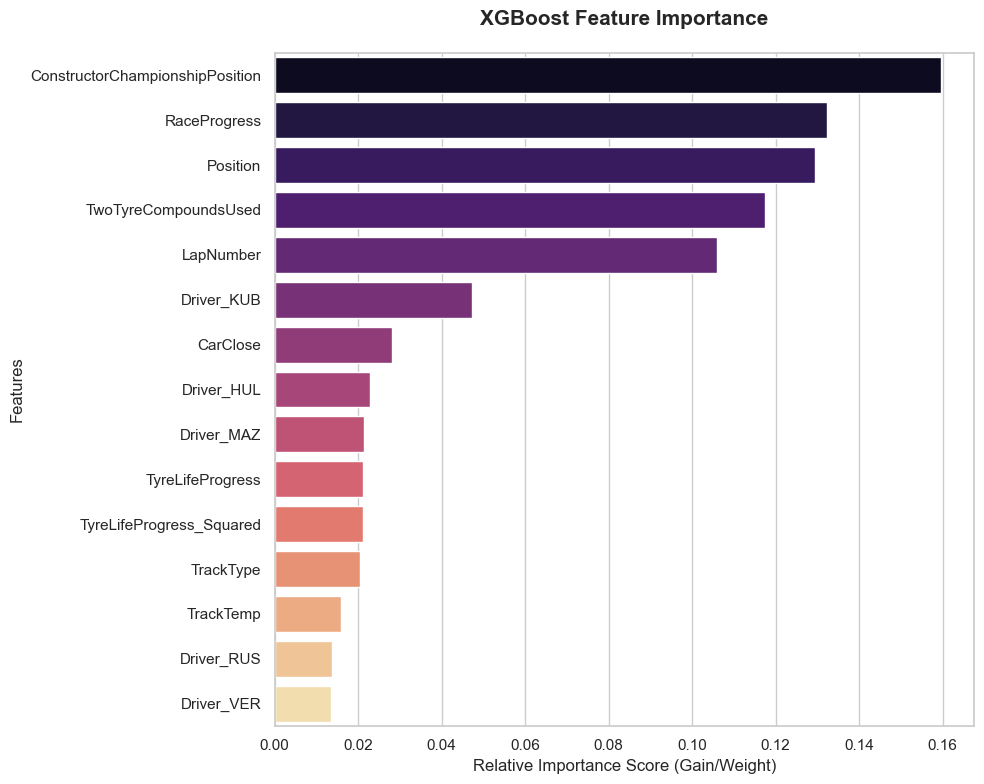


Top 5 Features for XGBoost Feature Importance:
                        Feature  Importance
ConstructorChampionshipPosition    0.159567
                   RaceProgress    0.132402
                       Position    0.129522
           TwoTyreCompoundsUsed    0.117513
                      LapNumber    0.105936


,Feature,Importance
0,ConstructorChampionshipPosition,0.159567
1,RaceProgress,0.132402
2,Position,0.129522
3,TwoTyreCompoundsUsed,0.117513
4,LapNumber,0.105936
5,Driver_KUB,0.047364
6,CarClose,0.027983
7,Driver_HUL,0.022708
8,Driver_MAZ,0.021318
9,TyreLifeProgress,0.021196


In [81]:
plot_xgb_feature_importance(best_xgb_model, X_train_xgb.columns)

🏁 Evaluating the Optimized Model on the Test Set...
Tuned MAE:  0.713 seconds
Tuned RMSE: 0.964 seconds


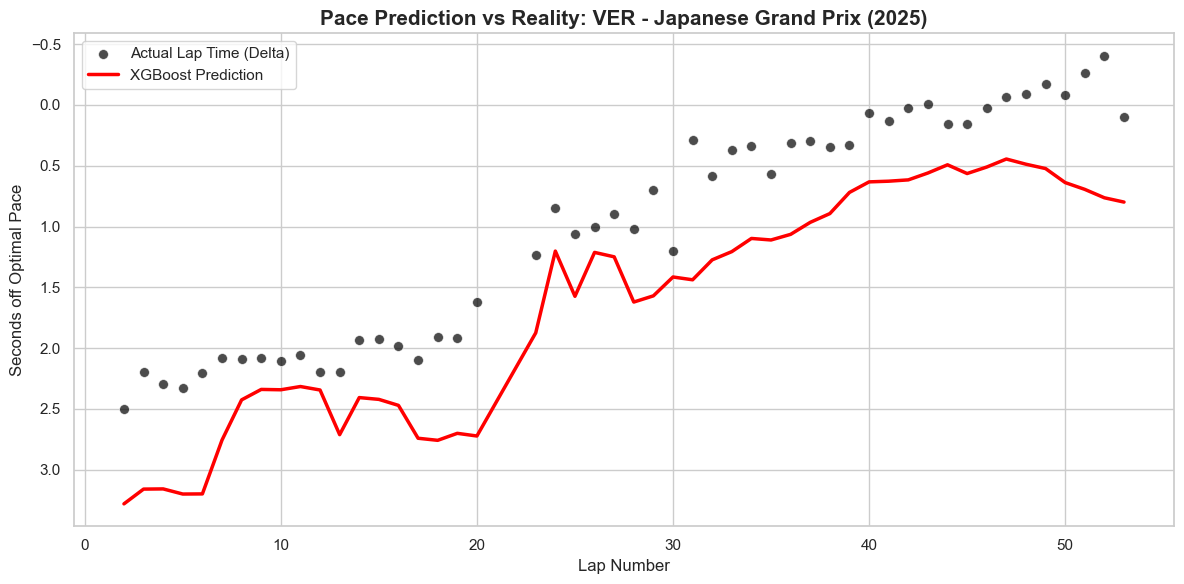

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set Seaborn theme
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. EVALUATE THE BEST MODEL ON UNSEEN TEST DATA
# ---------------------------------------------------------
print("🏁 Evaluating the Optimized Model on the Test Set...")

# random_search.best_estimator_ is already trained and ready!
y_pred_tuned = best_xgb_model.predict(X_test_xgb)

mae_tuned = mean_absolute_error(y_test_xgb, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_xgb, y_pred_tuned))

print(f"Tuned MAE:  {mae_tuned:.3f} seconds")
print(f"Tuned RMSE: {rmse_tuned:.3f} seconds")

# ---------------------------------------------------------
# 2. VISUALIZE PREDICTIONS VS REALITY (TELEMETRY STYLE)
# ---------------------------------------------------------
# Attach predictions back to our test dataframe
df_test_plot = df_test_xgb.copy()
df_test_plot['Predicted_LapDelta'] = y_pred_tuned

# Choose a random GP and Driver from the test set to visualize
sample_gp = df_test_plot['GP'].iloc[0]
target_driver = 'VER' # Change this to your preferred driver!

# Filter data
df_plot = df_test_plot[(df_test_plot['GP'] == sample_gp) & (df_test_plot['Driver_VER'] == 1)]

# If you used Label Encoding or if Driver_VER doesn't exist, use this fallback:
if df_plot.empty:
    # Try finding the first available driver in this GP
    first_driver_col = [col for col in df_test_plot.columns if col.startswith('Driver_') and df_test_plot[df_test_plot['GP'] == sample_gp][col].sum() > 0][0]
    df_plot = df_test_plot[(df_test_plot['GP'] == sample_gp) & (df_test_plot[first_driver_col] == 1)]
    target_driver = first_driver_col.replace('Driver_', '')

if not df_plot.empty:
    plt.figure(figsize=(12, 6))

    # Plot Actual Lap Delta (Scatter points for reality)
    sns.scatterplot(
        data=df_plot, 
        x='LapNumber', 
        y='LapDeltaSeconds', 
        color='black', 
        label='Actual Lap Time (Delta)',
        s=50,
        alpha=0.7
    )

    # Plot Predicted Lap Delta (Smooth line for the AI's "physics engine")
    sns.lineplot(
        data=df_plot, 
        x='LapNumber', 
        y='Predicted_LapDelta', 
        color='red', 
        linewidth=2.5,
        label='XGBoost Prediction'
    )

    # Formatting
    current_year = df_plot['Year'].iloc[0]
    plt.title(f"Pace Prediction vs Reality: {target_driver} - {sample_gp} ({current_year})", fontsize=15, fontweight='bold')
    plt.xlabel("Lap Number", fontsize=12)
    plt.ylabel("Seconds off Optimal Pace", fontsize=12)
    plt.legend(loc='upper left')
    
    # Invert Y axis so "faster" laps (lower delta) are higher up, like in real F1 telemetry
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find data for {target_driver} in {sample_gp}.")

### SAVING

In [82]:
import joblib

# ---------------------------------------------------------
# 1. SAVE THE OPTIMIZED XGBOOST MODEL
# ---------------------------------------------------------
# We save the model found by RandomizedSearch
xgb_filename = 'f1_pace_model_v4_optimized.joblib'

try:
    joblib.dump(best_xgb_model, xgb_filename)
    print(f"✅ XGBoost model successfully saved as '{xgb_filename}'")
except Exception as e:
    print(f"❌ Error saving the model: {e}")

# ---------------------------------------------------------
# 2. VERIFY THE SAVE (Optional)
# ---------------------------------------------------------
# Let's try to reload it to ensure integrity
loaded_model = joblib.load(xgb_filename)
print("🔍 Integrity check: Model reloaded successfully.")

# Quick test prediction to compare with the original
test_pred_original = best_xgb_model.predict(X_test_xgb.head(1))
test_pred_loaded = loaded_model.predict(X_test_xgb.head(1))

if np.isclose(test_pred_original, test_pred_loaded):
    print("💎 Validation passed: Predictions match perfectly!")

✅ XGBoost model successfully saved as 'f1_pace_model_v4_optimized.joblib'
🔍 Integrity check: Model reloaded successfully.
💎 Validation passed: Predictions match perfectly!


# SIMULATION

In [3]:
import tensorflow as tf
import joblib

# ---------------------------------------------------------
# 1. LOAD THE NEURAL NETWORK MODEL V3
# ---------------------------------------------------------
nn_model = tf.keras.models.load_model('f1_strategic_model_m10_v3.keras')

# ---------------------------------------------------------
# 2. LOAD THE OPTIMIZED XGBOOST MODEL V4
# ---------------------------------------------------------
best_xgb_model = joblib.load('f1_pace_model_v4_optimized.joblib')

In [9]:
print("NN expects these columns:", X_train_nn.columns.tolist())
print("\nXGB dataset has these columns:", X_test_xgb.columns.tolist())

NN expects these columns: ['Position', 'TrackTemp', 'RaceProgress', 'TyreLifeProgress', 'CarClose', 'PitStopBehind', 'TwoTyreCompoundsUsed', 'TrackType', 'ConstructorChampionshipPosition', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 'CleanTrackStatus_GreenFlag', 'CleanTrackStatus_RedFlag', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 'CleanTrackStatus_YellowFlag']

XGB dataset has these columns: ['LapNumber', 'Position', 'TrackTemp', 'RaceProgress', 'TyreLifeProgress', 'TyreLifeProgress_Squared', 'TrackType', 'TwoTyreCompoundsUsed', 'CarClose', 'ConstructorChampionshipPosition', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 'Driver_ALB', 'Driver_ALO', 'Driver_ANT', 'Driver_BEA', 'Driver_BOR', 'Driver_BOT', 'Driver_COL', 'Driver_DEV', 'Driver_DOO', 'Driver_FIT', 'Driver_GAS', 'Driver_GIO', 'Driver_GRO', 'Driver_HAD', 'Driver_HAM', 'Driver_HUL', 'Driver_KUB', 'Driver_KVY', 'Driver_LAT', 'Driver_LAW', 'Driver_LEC', 'Driver_MAG', 'Driver_MAZ', 'Driver_MSC', 'Driver

In [10]:
nn_features = X_train_nn.columns.tolist()
xgb_features = X_train_xgb.columns.tolist()

### TESTING THE SIMULATION WITH REAL RACE EVENTS

In [105]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. DEFINE EXACT FEATURE LISTS
# ---------------------------------------------------------
# Based on the exact lists you provided for each model
nn_features = [
    'Position', 'TrackTemp', 'RaceProgress', 'TyreLifeProgress', 'CarClose', 
    'PitStopBehind', 'TwoTyreCompoundsUsed', 'TrackType', 'ConstructorChampionshipPosition', 
    'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 'CleanTrackStatus_GreenFlag', 
    'CleanTrackStatus_RedFlag', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 
    'CleanTrackStatus_YellowFlag'
]

xgb_features = [
    'LapNumber', 'Position', 'TrackTemp', 'RaceProgress', 'TyreLifeProgress', 
    'TyreLifeProgress_Squared', 'TrackType', 'TwoTyreCompoundsUsed', 'CarClose', 
    'ConstructorChampionshipPosition', 'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT', 
    'Driver_ALB', 'Driver_ALO', 'Driver_ANT', 'Driver_BEA', 'Driver_BOR', 'Driver_BOT', 
    'Driver_COL', 'Driver_DEV', 'Driver_DOO', 'Driver_FIT', 'Driver_GAS', 'Driver_GIO', 
    'Driver_GRO', 'Driver_HAD', 'Driver_HAM', 'Driver_HUL', 'Driver_KUB', 'Driver_KVY', 
    'Driver_LAT', 'Driver_LAW', 'Driver_LEC', 'Driver_MAG', 'Driver_MAZ', 'Driver_MSC', 
    'Driver_NOR', 'Driver_OCO', 'Driver_PER', 'Driver_PIA', 'Driver_RAI', 'Driver_RIC', 
    'Driver_RUS', 'Driver_SAI', 'Driver_SAR', 'Driver_STR', 'Driver_TSU', 'Driver_VER', 
    'Driver_VET', 'Driver_ZHO'
]

# ---------------------------------------------------------
# 2. RACE SIMULATOR FUNCTION
# ---------------------------------------------------------
def run_clean_race_simulation(df_master, gp_name, driver_code, year, nn_model, xgb_model):
    """
    Simulates a race lap-by-lap for a specific driver.
    Dynamically updates tyre age and asks the models for predictions.
    """
    print(f"--- 🏁 STARTING AI SIMULATION: {driver_code} @ {gp_name} ({year}) ---")
    
    # Identify the specific one-hot column for the driver
    driver_col = f'Driver_{driver_code}'
    
    # 1. Extract the specific race data for this driver from the master dataset
    race_data = df_master[(df_master['GP'] == gp_name) & 
                          (df_master['Year'] == year) & 
                          (df_master[driver_col] == 1)].copy()
    
    # Ensure it's sorted chronologically by lap
    race_data = race_data.sort_values('LapNumber')
    
    if race_data.empty:
        print(f"❌ Error: No data found for {driver_code} in {gp_name} {year}.")
        return None

    # 2. Initialize Simulation Variables
    simulated_tyre_age = 0
    last_pit_lap = 0
    max_tyre_life_assumption = 40.0 # Used to normalize tyre progress
    min_stint_laps = 12 # Prevent pitting too early after a previous stop
    
    simulation_logs = []

    # 3. Lap-by-Lap Loop (Using range and iloc to preserve data types)
    for i in range(len(race_data)):
        
        # Extract the single row as a DataFrame directly to keep float/int types intact
        current_lap_df = race_data.iloc[[i]].copy()
        
        # Extract lap number for our logic
        lap_num = int(current_lap_df['LapNumber'].iloc[0])
        
        # --- INJECT SIMULATED TYRE WEAR ---
        tyre_progress = simulated_tyre_age / max_tyre_life_assumption
        current_lap_df['TyreLifeProgress'] = tyre_progress
        current_lap_df['TyreLifeProgress_Squared'] = tyre_progress ** 2
        
        # --- PREDICT WITH XGBOOST (PACE) ---
        xgb_input = current_lap_df[xgb_features]
        predicted_pace_delta = xgb_model.predict(xgb_input)[0]
        
        # --- PREDICT WITH NEURAL NETWORK (STRATEGY) ---
        nn_input = current_lap_df[nn_features]
        predicted_pit_prob = nn_model.predict(nn_input, verbose=0)[0][0]
        
        # --- DECISION LOGIC ---
        laps_since_pit = lap_num - last_pit_lap
        
        # Check if Safety Car or VSC is active
        is_safety_car = int(current_lap_df['CleanTrackStatus_SafetyCar'].iloc[0]) == 1 or \
                        int(current_lap_df['CleanTrackStatus_VSC'].iloc[0]) == 1
        
        action_taken = "STAY OUT"
        
        # Strategy Rule 1: Standard degradation pit stop
        if predicted_pit_prob > 0.65 and laps_since_pit >= min_stint_laps:
            action_taken = "BOX (STRATEGY)"
            simulated_tyre_age = 0
            last_pit_lap = lap_num
            
        # Strategy Rule 2: Opportunistic pit stop under Safety Car/VSC
        elif is_safety_car and predicted_pit_prob > 0.40 and laps_since_pit >= 5:
            action_taken = "BOX (SAFETY CAR)"
            simulated_tyre_age = 0
            last_pit_lap = lap_num
            
        else:
            simulated_tyre_age += 1

        # --- LOG THE RESULTS ---
        simulation_logs.append({
            'Lap': lap_num,
            'Sim_TyreAge_StartOfLap': simulated_tyre_age - 1 if action_taken == "STAY OUT" else 0,
            'AI_Pace_Delta': round(predicted_pace_delta, 3),
            'AI_Pit_Prob': round(predicted_pit_prob, 3),
            'Action': action_taken
        })
        
        # Print lap status to console
        print(f"Lap {lap_num:02d} | TyreAge: {simulation_logs[-1]['Sim_TyreAge_StartOfLap']:02d} | "
              f"PaceDelta: {predicted_pace_delta:+.2f}s | PitProb: {predicted_pit_prob:.3f} | {action_taken}")

    print("--- 🏁 SIMULATION COMPLETE ---")
    
    # Return as a clean DataFrame for further analysis
    return pd.DataFrame(simulation_logs)

In [117]:
import pandas as pd
import numpy as np

def run_clean_race_simulation(df_master, gp_name, driver_code, year, nn_model, xgb_model):
    """
    Simulates a race lap-by-lap for a specific driver.
    Dynamically updates tyre age, manages tyre compounds, and asks the models for predictions.
    """
    print(f"--- 🏁 STARTING AI SIMULATION: {driver_code} @ {gp_name} ({year}) ---")
    
    # Identify the specific one-hot column for the driver
    driver_col = f'Driver_{driver_code}'
    
    # 1. Extract the specific race data for this driver from the master dataset
    race_data = df_master[(df_master['GP'] == gp_name) & 
                          (df_master['Year'] == year) & 
                          (df_master[driver_col] == 1)].copy()
    
    # Ensure it's sorted chronologically by lap
    race_data = race_data.sort_values('LapNumber')
    
    if race_data.empty:
        print(f"❌ Error: No data found for {driver_code} in {gp_name} {year}.")
        return None

    # 2. Initialize Simulation Variables
    simulated_tyre_age = 0
    last_pit_lap = 0
    max_tyre_life_assumption = 40.0 # Used to normalize tyre progress
    min_stint_laps = 12 # Prevent pitting too early after a previous stop
    
    # --- TYRE MANAGER: Setup Starting Compound ---
    first_lap = race_data.iloc[0]
    if first_lap['Compound_SOFT'] == 1:
        current_compound = 'SOFT'
    elif first_lap['Compound_HARD'] == 1:
        current_compound = 'HARD'
    else:
        current_compound = 'MEDIUM' # Default fallback
        
    has_pitted_in_sim = False
    print(f"🏎️ Starting Race on: {current_compound} tyres\n")
    
    simulation_logs = []

    # 3. Lap-by-Lap Loop (Using range and iloc to preserve data types)
    for i in range(len(race_data)):
        
        # Extract the single row as a DataFrame directly to keep float/int types intact
        current_lap_df = race_data.iloc[[i]].copy()
        
        # Extract lap number for our logic
        lap_num = int(current_lap_df['LapNumber'].iloc[0])
        
        # --- INJECT SIMULATED TYRE WEAR ---
        tyre_progress = simulated_tyre_age / max_tyre_life_assumption
        current_lap_df['TyreLifeProgress'] = tyre_progress
        current_lap_df['TyreLifeProgress_Squared'] = tyre_progress ** 2
        
        # --- INJECT SIMULATED TYRE COMPOUND (TYRE MANAGER) ---
        # 1. Reset all compound columns to 0, overriding historical reality
        current_lap_df['Compound_SOFT'] = 0
        current_lap_df['Compound_MEDIUM'] = 0
        current_lap_df['Compound_HARD'] = 0
        
        # 2. Activate only our simulated current compound
        current_lap_df[f'Compound_{current_compound}'] = 1
        
        # 3. Update the mandatory two-compound rule based on our simulation
        current_lap_df['TwoTyreCompoundsUsed'] = 1 if has_pitted_in_sim else 0
        
        # --- PREDICT WITH XGBOOST (PACE) ---
        xgb_input = current_lap_df[xgb_features]
        predicted_pace_delta = xgb_model.predict(xgb_input)[0]
        
        # --- PREDICT WITH NEURAL NETWORK (STRATEGY) ---
        nn_input = current_lap_df[nn_features]
        predicted_pit_prob = nn_model.predict(nn_input, verbose=0)[0][0]
        
        # --- DECISION LOGIC ---
        laps_since_pit = lap_num - last_pit_lap
        
        # Check if Safety Car or VSC is active
        is_safety_car = int(current_lap_df['CleanTrackStatus_SafetyCar'].iloc[0]) == 1 or \
                        int(current_lap_df['CleanTrackStatus_VSC'].iloc[0]) == 1
        
        action_taken = "STAY OUT"
        next_compound = current_compound # Keep track of the compound if we don't pit
        
        # Strategy Rule 1: Standard degradation pit stop
        if predicted_pit_prob > 0.65 and laps_since_pit >= min_stint_laps:
            action_taken = "BOX (STRATEGY)"
            simulated_tyre_age = 0
            last_pit_lap = lap_num
            has_pitted_in_sim = True
            
            # Tyre Manager: Swap Logic (Soft/Med -> Hard, Hard -> Med)
            next_compound = 'HARD' if current_compound in ['SOFT', 'MEDIUM'] else 'MEDIUM'
            
        # Strategy Rule 2: Opportunistic pit stop under Safety Car/VSC
        elif is_safety_car and predicted_pit_prob > 0.40 and laps_since_pit >= 5:
            action_taken = "BOX (SAFETY CAR)"
            simulated_tyre_age = 0
            last_pit_lap = lap_num
            has_pitted_in_sim = True
            
            # Tyre Manager: Swap Logic
            next_compound = 'HARD' if current_compound in ['SOFT', 'MEDIUM'] else 'MEDIUM'
            
        else:
            simulated_tyre_age += 1

        # --- LOG THE RESULTS ---
        simulation_logs.append({
            'Lap': lap_num,
            'Sim_TyreAge_StartOfLap': simulated_tyre_age - 1 if action_taken == "STAY OUT" else 0,
            'Sim_Compound': current_compound, # Track the active compound
            'AI_Pace_Delta': round(predicted_pace_delta, 3),
            'AI_Pit_Prob': round(predicted_pit_prob, 3),
            'Action': action_taken
        })
        
        # Print lap status to console (Now including the compound!)
        print(f"Lap {lap_num:02d} [{current_compound[0]}] | TyreAge: {simulation_logs[-1]['Sim_TyreAge_StartOfLap']:02d} | "
              f"PaceDelta: {predicted_pace_delta:+.2f}s | PitProb: {predicted_pit_prob:.3f} | {action_taken}")

        # Update the compound for the NEXT lap if we pitted
        if "BOX" in action_taken:
            print(f"  └─ 🔧 PIT CREW: Swapping {current_compound} for {next_compound} tyres!")
            current_compound = next_compound

    print("--- 🏁 SIMULATION COMPLETE ---")
    
    # Return as a clean DataFrame for further analysis
    return pd.DataFrame(simulation_logs)

In [ ]:
# Run the simulation for Max Verstappen at the Japanese Grand Prix
simulation_results = run_clean_race_simulation(
    df_master=df_race, # or df_race, depending on what you named your final dataset
    gp_name='Japanese Grand Prix',
    driver_code='VER',
    year=2025, # Adjust the year based on your dataset!
    nn_model=nn_model,
    xgb_model=best_xgb_model
)

--- 🏁 STARTING AI SIMULATION: VER @ Japanese Grand Prix (2025) ---
🏎️ Starting Race on: MEDIUM tyres

Lap 01 [M] | TyreAge: 00 | PaceDelta: +5.23s | PitProb: 0.004 | STAY OUT
Lap 02 [M] | TyreAge: 01 | PaceDelta: +5.27s | PitProb: 0.006 | STAY OUT
Lap 03 [M] | TyreAge: 02 | PaceDelta: +3.26s | PitProb: 0.009 | STAY OUT
Lap 04 [M] | TyreAge: 03 | PaceDelta: +3.08s | PitProb: 0.013 | STAY OUT
Lap 05 [M] | TyreAge: 04 | PaceDelta: +3.11s | PitProb: 0.019 | STAY OUT
Lap 06 [M] | TyreAge: 05 | PaceDelta: +3.13s | PitProb: 0.026 | STAY OUT
Lap 07 [M] | TyreAge: 06 | PaceDelta: +2.72s | PitProb: 0.089 | STAY OUT
Lap 08 [M] | TyreAge: 07 | PaceDelta: +2.39s | PitProb: 0.106 | STAY OUT
Lap 09 [M] | TyreAge: 08 | PaceDelta: +2.28s | PitProb: 0.131 | STAY OUT
Lap 10 [M] | TyreAge: 09 | PaceDelta: +2.29s | PitProb: 0.163 | STAY OUT
Lap 11 [M] | TyreAge: 10 | PaceDelta: +2.24s | PitProb: 0.206 | STAY OUT
Lap 12 [M] | TyreAge: 11 | PaceDelta: +2.24s | PitProb: 0.252 | STAY OUT
Lap 13 [M] | TyreAge: 

In [124]:
# Run the simulation for Max Verstappen at the Japanese Grand Prix
simulation_results = run_clean_race_simulation(
    df_master=df_race, # or df_race, depending on what you named your final dataset
    gp_name='Emilia Romagna Grand Prix',
    driver_code='VER',
    year=2025, # Adjust the year based on your dataset!
    nn_model=nn_model,
    xgb_model=best_xgb_model
)

--- 🏁 STARTING AI SIMULATION: VER @ Emilia Romagna Grand Prix (2025) ---
🏎️ Starting Race on: MEDIUM tyres

Lap 01 [M] | TyreAge: 00 | PaceDelta: +4.29s | PitProb: 0.001 | STAY OUT
Lap 02 [M] | TyreAge: 01 | PaceDelta: +4.29s | PitProb: 0.001 | STAY OUT
Lap 03 [M] | TyreAge: 02 | PaceDelta: +1.64s | PitProb: 0.001 | STAY OUT
Lap 04 [M] | TyreAge: 03 | PaceDelta: +1.46s | PitProb: 0.002 | STAY OUT
Lap 05 [M] | TyreAge: 04 | PaceDelta: +1.44s | PitProb: 0.002 | STAY OUT
Lap 06 [M] | TyreAge: 05 | PaceDelta: +1.41s | PitProb: 0.003 | STAY OUT
Lap 07 [M] | TyreAge: 06 | PaceDelta: +1.41s | PitProb: 0.005 | STAY OUT
Lap 08 [M] | TyreAge: 07 | PaceDelta: +1.40s | PitProb: 0.006 | STAY OUT
Lap 09 [M] | TyreAge: 08 | PaceDelta: +1.39s | PitProb: 0.009 | STAY OUT
Lap 10 [M] | TyreAge: 09 | PaceDelta: +1.12s | PitProb: 0.036 | STAY OUT
Lap 11 [M] | TyreAge: 10 | PaceDelta: +1.11s | PitProb: 0.047 | STAY OUT
Lap 12 [M] | TyreAge: 11 | PaceDelta: +1.11s | PitProb: 0.063 | STAY OUT
Lap 13 [M] | Tyr

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_simulation_dashboard(sim_df, driver_code, gp_name, year):
    """
    Creates a visual dashboard of the race simulation, plotting both 
    XGBoost Pace Delta and Neural Network Pit Stop Probability.
    """
    # 1. Setup the figure and subplots (2 rows, 1 column)
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"AI Strategy Dashboard: {driver_code} @ {gp_name} ({year})", 
                 fontsize=16, fontweight='bold')

    # ---------------------------------------------------------
    # TOP PLOT: XGBoost Pace Delta (Fuel Burn vs Tyre Wear)
    # ---------------------------------------------------------
    sns.lineplot(data=sim_df, x='Lap', y='AI_Pace_Delta', ax=ax1, 
                 color='#1f77b4', linewidth=2.5, label='Pace Delta (Seconds)')
    
    ax1.set_title("XGBoost: Predicted Pace Delta (Lower is Faster)", fontsize=12)
    ax1.set_ylabel("Delta vs Baseline (s)", fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # ---------------------------------------------------------
    # BOTTOM PLOT: Neural Network Pit Stop Probability
    # ---------------------------------------------------------
    sns.lineplot(data=sim_df, x='Lap', y='AI_Pit_Prob', ax=ax2, 
                 color='#d62728', linewidth=2.5, label='Pit Probability')
    
    # Add a horizontal line for our decision threshold (0.65)
    ax2.axhline(y=0.65, color='orange', linestyle='--', linewidth=2, label='Box Threshold (65%)')
    
    ax2.set_title("Neural Network: Pit Stop Probability", fontsize=12)
    ax2.set_ylabel("Probability (0.0 to 1.0)", fontsize=11)
    ax2.set_xlabel("Lap Number", fontsize=12)
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, linestyle='--', alpha=0.6)

    # ---------------------------------------------------------
    # HIGHLIGHT THE PIT STOPS ON BOTH GRAPHS
    # ---------------------------------------------------------
    # Filter laps where the 'Action' column contains the word 'BOX'
    pit_laps = sim_df[sim_df['Action'].str.contains("BOX")]['Lap'].tolist()

    for pit_lap in pit_laps:
        # Draw vertical line on the Pace graph
        ax1.axvline(x=pit_lap, color='black', linestyle='-.', linewidth=2)
        ax1.text(pit_lap + 0.5, sim_df['AI_Pace_Delta'].max() * 0.9, 'BOX CALLED', 
                 color='black', fontweight='bold', rotation=90)
        
        # Draw vertical line on the Probability graph
        ax2.axvline(x=pit_lap, color='black', linestyle='-.', linewidth=2)

    # Clean up layout and display
    plt.tight_layout()
    plt.show()

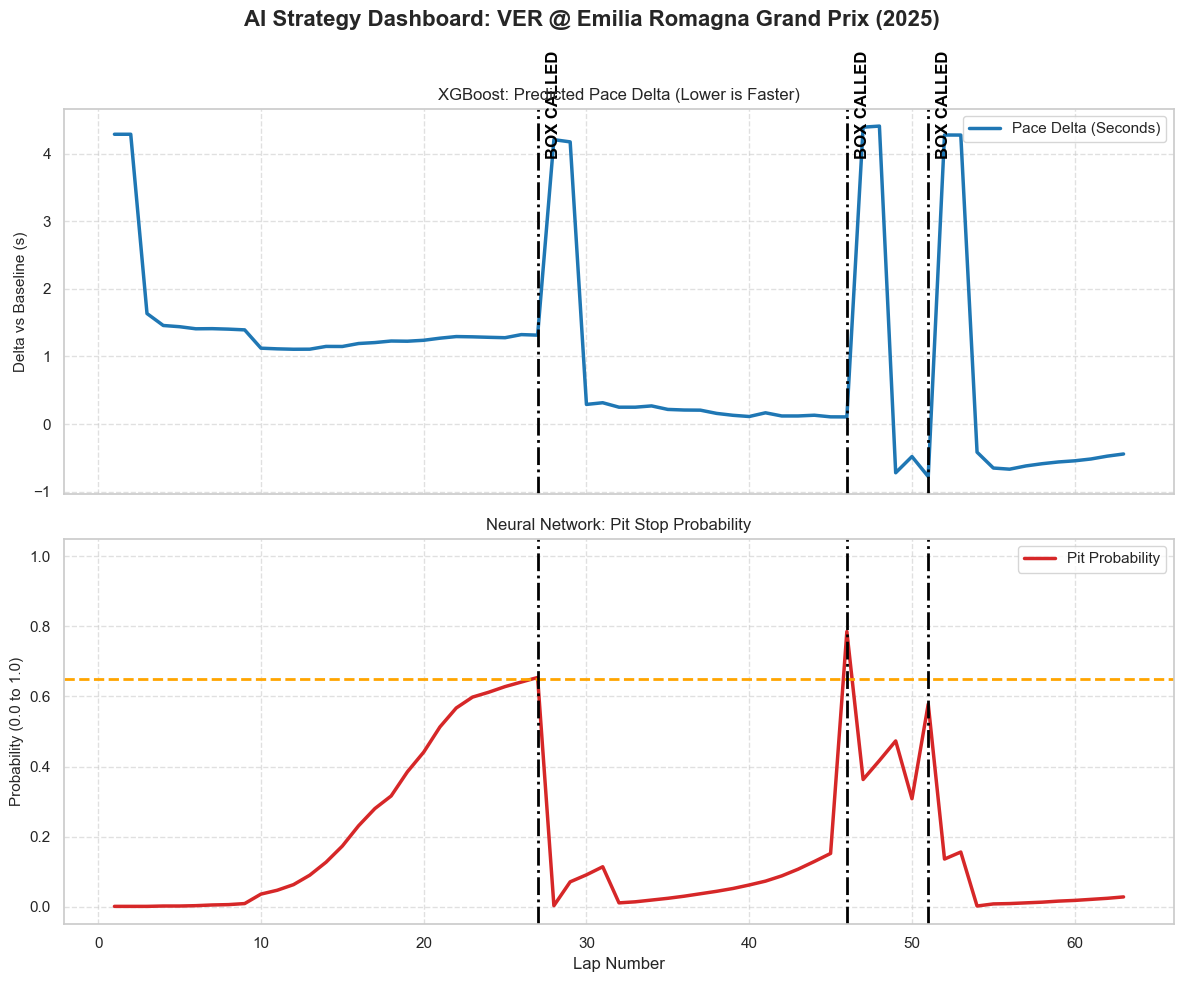

In [125]:
# ---------------------------------------------------------
# HOW TO USE IT:
# ---------------------------------------------------------
# Assuming 'simulation_results' is the DataFrame you just printed:
# plot_simulation_dashboard(simulation_results, 'VER', 'Japanese Grand Prix', 2025)
plot_simulation_dashboard(simulation_results, 'VER', 'Emilia Romagna Grand Prix', 2025)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_simulation_vs_reality(sim_df, real_df, driver_code, gp_name, year):
    """
    Creates a visual dashboard comparing the AI's race simulation 
    against the real-world historical data.
    """
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"AI vs Reality: {driver_code} @ {gp_name} ({year})", 
                 fontsize=16, fontweight='bold')

    # ---------------------------------------------------------
    # TOP PLOT: Pace Delta (AI Line vs Real Scatter)
    # ---------------------------------------------------------
    # 1. AI Predicted Pace (Line)
    sns.lineplot(data=sim_df, x='Lap', y='AI_Pace_Delta', ax=ax1, 
                 color='#1f77b4', linewidth=2.5, label='AI Predicted Pace')
    
    # 2. Real World Pace (Scatter)
    # We use LapNumber and LapDeltaSeconds from the original dataset
    real_pace_clean = real_df[real_df['LapDeltaSeconds'] < 10.0]
    sns.scatterplot(data=real_pace_clean, x='LapNumber', y='LapDeltaSeconds', ax=ax1,
                    color='gray', alpha=0.6, s=50, label='Real Pace (Actual)')
    
    ax1.set_title("Pace Delta: AI Prediction vs Real Lap Times", fontsize=12)
    ax1.set_ylabel("Delta vs Baseline (s)", fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)

    y_max = max(sim_df['AI_Pace_Delta'].max(), real_pace_clean['LapDeltaSeconds'].max()) + 1.0
    y_min = min(sim_df['AI_Pace_Delta'].min(), real_pace_clean['LapDeltaSeconds'].min()) - 0.5
    ax1.set_ylim(y_min, y_max)
    
    # ---------------------------------------------------------
    # BOTTOM PLOT: Neural Network Pit Stop Probability
    # ---------------------------------------------------------
    sns.lineplot(data=sim_df, x='Lap', y='AI_Pit_Prob', ax=ax2, 
                 color='#d62728', linewidth=2.5, label='AI Pit Probability')
    
    ax2.axhline(y=0.65, color='orange', linestyle='--', linewidth=2, label='Box Threshold (65%)')
    
    ax2.set_title("Neural Network: Strategic Confidence", fontsize=12)
    ax2.set_ylabel("Probability (0.0 to 1.0)", fontsize=11)
    ax2.set_xlabel("Lap Number", fontsize=12)
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, linestyle='--', alpha=0.6)

    # ---------------------------------------------------------
    # HIGHLIGHT THE PIT STOPS (AI vs REAL)
    # ---------------------------------------------------------
    # A) AI Pit Stops (Black Dash-Dot Line)
    ai_pit_laps = sim_df[sim_df['Action'].str.contains("BOX")]['Lap'].tolist()
    for pit_lap in ai_pit_laps:
        ax1.axvline(x=pit_lap, color='black', linestyle='-.', linewidth=2)
        ax1.text(pit_lap + 0.3, ax1.get_ylim()[1] * 0.85, 'AI BOX', 
                 color='black', fontweight='bold', rotation=90)
        ax2.axvline(x=pit_lap, color='black', linestyle='-.', linewidth=2)

    # B) Real Pit Stops (Green Dotted Line)
    real_pit_laps = real_df[real_df['InPits'] == 1]['LapNumber'].tolist()
    for pit_lap in real_pit_laps:
        ax1.axvline(x=pit_lap, color='green', linestyle=':', linewidth=2.5)
        ax1.text(pit_lap - 0.8, ax1.get_ylim()[1] * 0.85, 'REAL BOX', 
                 color='green', fontweight='bold', rotation=90)
        ax2.axvline(x=pit_lap, color='green', linestyle=':', linewidth=2.5)

    # Clean up layout and display
    plt.tight_layout()
    plt.show()

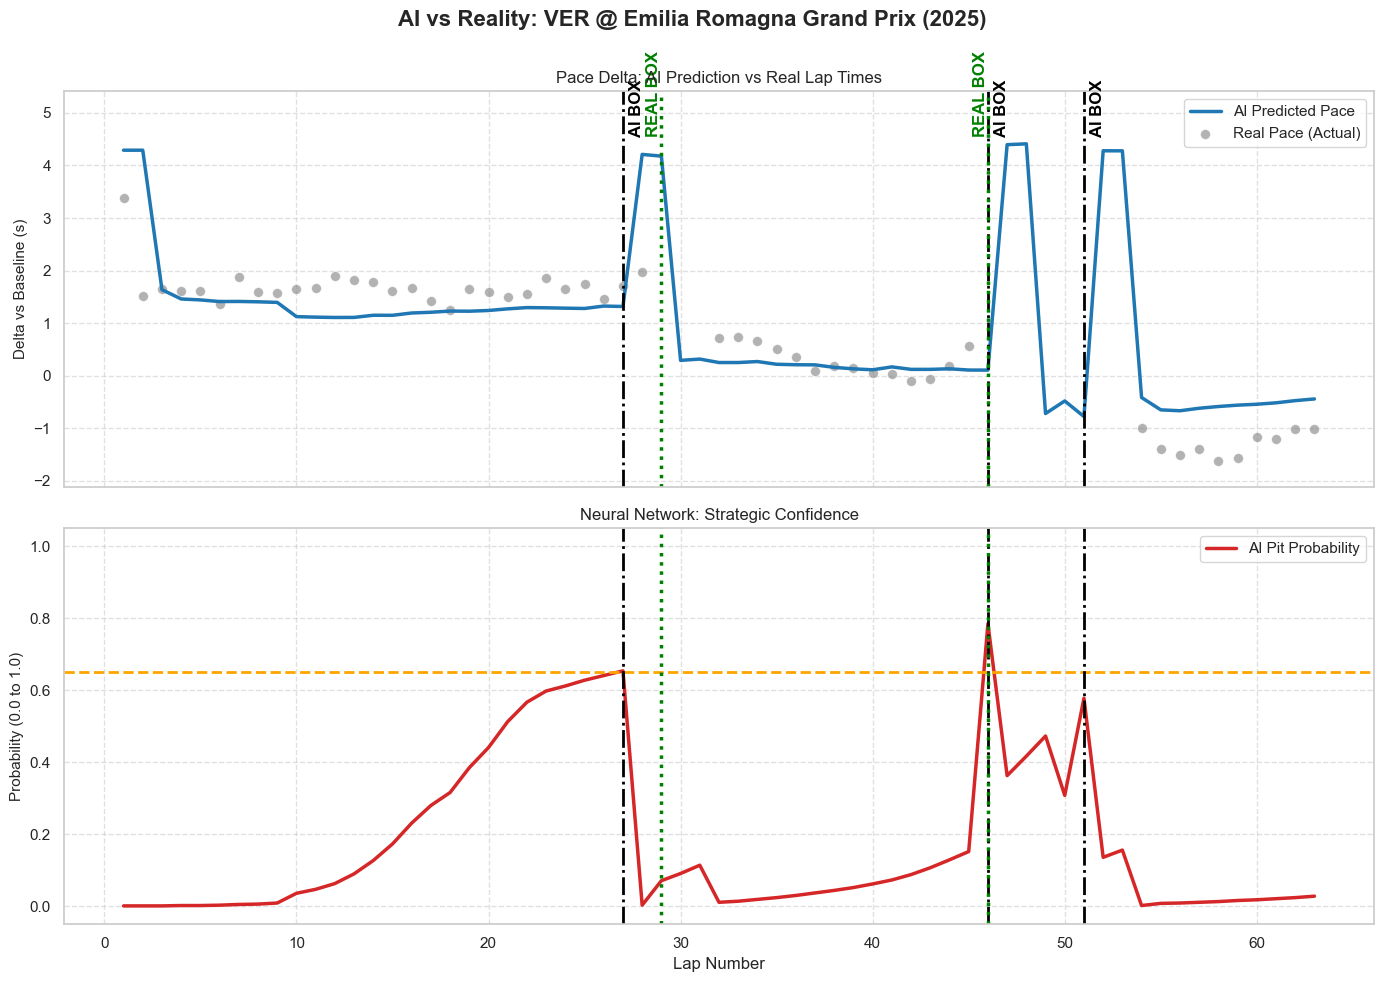

In [126]:
# 1. Real data for Max at Japanese Grand Prix
real_race_data = df_race[(df_race['GP'] == 'Emilia Romagna Grand Prix') & 
                         (df_race['Driver_VER'] == 1) & 
                         (df_race['Year'] == 2025)] # Assicurati che l'anno sia quello giusto!

# 2. Generate comparative graph
plot_simulation_vs_reality(
    sim_df=simulation_results, 
    real_df=real_race_data, 
    driver_code='VER', 
    gp_name='Emilia Romagna Grand Prix', 
    year=2025
)

### COMPLETE SIMULATION

In [129]:
import pandas as pd
import numpy as np
import copy

def run_strategy_optimizer(df_master, gp_name, driver_code, year, nn_model, xgb_model, xgb_features, nn_features):
    print(f"--- 🧠 STRATEGY OPTIMIZER: {driver_code} @ {gp_name} ({year}) ---")
    
    driver_col = f'Driver_{driver_code}'
    race_data = df_master[(df_master['GP'] == gp_name) & 
                          (df_master['Year'] == year) & 
                          (df_master[driver_col] == 1)].sort_values('LapNumber').copy()
    
    if race_data.empty:
        print("❌ Error: No data found.")
        return None

    # --- SIMULATION PARAMETERS ---
    NORMAL_PIT_LOSS = 28.0   
    SC_PIT_LOSS = 14.0       
    MAX_PIT_STOPS = 3        
    MIN_STINT_LAPS = 8       
    NN_PIT_THRESHOLD = 0.20  
    BEAM_WIDTH = 100         
    MAX_TYRE_LIFE = 40.0

    # Nuovi limiti vitali delle mescole (dopo i quali scatta il "Cliff")
    CLIFF_LAPS = {
        'SOFT': 22,
        'MEDIUM': 38,
        'HARD': 55
    }

    # Define the initial states
    compounds = ['SOFT', 'MEDIUM', 'HARD']
    active_states = []
    
    for comp in compounds:
        active_states.append({
            'total_time_delta': 0.0,
            'current_compound': comp,
            'tyre_age': 0,
            'pit_stops': 0,
            'compounds_used': {comp},
            'last_pit_lap': 0,
            'log': [f"Start on {comp}"]
        })

    # --- MAIN LAP-BY-LAP LOOP ---
    for i in range(len(race_data)):
        current_lap_df_base = race_data.iloc[[i]].copy()
        lap_num = int(current_lap_df_base['LapNumber'].iloc[0])
        
        is_sc = int(current_lap_df_base['CleanTrackStatus_SafetyCar'].iloc[0]) == 1 or \
                int(current_lap_df_base['CleanTrackStatus_VSC'].iloc[0]) == 1
        
        current_pit_loss = SC_PIT_LOSS if is_sc else NORMAL_PIT_LOSS
        
        next_states = []

        for state in active_states:
            sim_df = current_lap_df_base.copy()
            
            tyre_prog = state['tyre_age'] / MAX_TYRE_LIFE
            sim_df['TyreLifeProgress'] = tyre_prog
            sim_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
            
            sim_df['Compound_SOFT'] = 1 if state['current_compound'] == 'SOFT' else 0
            sim_df['Compound_MEDIUM'] = 1 if state['current_compound'] == 'MEDIUM' else 0
            sim_df['Compound_HARD'] = 1 if state['current_compound'] == 'HARD' else 0
            
            sim_df['TwoTyreCompoundsUsed'] = 1 if len(state['compounds_used']) > 1 else 0
            
            xgb_input = sim_df[xgb_features]
            nn_input = sim_df[nn_features]
            
            pace_delta = xgb_model.predict(xgb_input)[0]
            pit_prob = nn_model.predict(nn_input, verbose=0)[0][0]
            
            # --- TIRE CLIFF PENALTY ---
            # Se la gomma supera il suo limite vitale, aggiungiamo una penalità brutale (+2s, +4s, +6s per ogni giro extra)
            cliff_penalty = 0.0
            if state['tyre_age'] > CLIFF_LAPS[state['current_compound']]:
                laps_over_limit = state['tyre_age'] - CLIFF_LAPS[state['current_compound']]
                cliff_penalty = laps_over_limit * 2.5 # Perdi 2.5s al primo giro extra, 5s al secondo, ecc.
            
            # Aggiungiamo il pace delta di XGBoost + eventuale penalità del crollo gomma
            updated_time = state['total_time_delta'] + pace_delta + cliff_penalty
            
            # --- ACTION 1: STAY OUT ---
            stay_out_state = copy.deepcopy(state)
            stay_out_state['total_time_delta'] = updated_time
            stay_out_state['tyre_age'] += 1
            next_states.append(stay_out_state)
            
            # --- ACTION 2: PIT STOP ---
            laps_since_pit = lap_num - state['last_pit_lap']
            can_pit = state['pit_stops'] < MAX_PIT_STOPS and laps_since_pit >= MIN_STINT_LAPS
            
            should_explore_pit = (pit_prob > NN_PIT_THRESHOLD) or (is_sc and state['tyre_age'] >= 10)
            
            if can_pit and should_explore_pit:
                available_compounds = [c for c in compounds if c != state['current_compound']]
                
                for new_comp in available_compounds:
                    pit_state = copy.deepcopy(state)
                    pit_state['total_time_delta'] = updated_time + current_pit_loss
                    pit_state['current_compound'] = new_comp
                    pit_state['tyre_age'] = 0
                    pit_state['pit_stops'] += 1
                    pit_state['compounds_used'].add(new_comp)
                    pit_state['last_pit_lap'] = lap_num
                    
                    sc_tag = " (SC/VSC)" if is_sc else ""
                    pit_state['log'].append(f"Lap {lap_num}: BOX for {new_comp}{sc_tag}")
                    
                    next_states.append(pit_state)

        # --- BEAM SEARCH PRUNING ---
        # Sort all generated universes by total_time_delta and keep only the top BEAM_WIDTH
        # We add a tiny penalty to older tyres so it doesn't overly favor staying out endlessly without penalty
        next_states.sort(key=lambda x: x['total_time_delta'] + (x['tyre_age'] * 0.1))
        active_states = next_states[:BEAM_WIDTH]
        
        if lap_num % 10 == 0:
            print(f"🏁 Lap {lap_num} processed. Keeping top {len(active_states)} parallel strategies...")

    # --- POST-RACE FILTERING ---
    # Filter out illegal strategies (must use at least 2 different compounds)
    legal_strategies = [s for s in active_states if len(s['compounds_used']) >= 2]
    
    if not legal_strategies:
        print("❌ No legal strategies found (Two-Compound rule violated).")
        return None

    # Sort final legal strategies by best total time
    legal_strategies.sort(key=lambda x: x['total_time_delta'])
    
    print("\n🏆 OPTIMIZATION COMPLETE! TOP 3 STRATEGIES 🏆")
    print("-" * 50)
    for i, strat in enumerate(legal_strategies[:3]):
        print(f"Rank {i+1} | Pit Stops: {strat['pit_stops']} | Projected Total Delta: +{strat['total_time_delta']:.2f}s")
        print("Strategy Path: " + " ➡️ ".join(strat['log']))
        print("-" * 50)
        
    return legal_strategies

In [130]:
best_strategies = run_strategy_optimizer(
    df_race, 'Emilia Romagna Grand Prix', 'VER', 2025, 
    nn_model, best_xgb_model, xgb_features, nn_features
)

--- 🧠 STRATEGY OPTIMIZER: VER @ Emilia Romagna Grand Prix (2025) ---
🏁 Lap 10 processed. Keeping top 3 parallel strategies...
🏁 Lap 20 processed. Keeping top 13 parallel strategies...
🏁 Lap 30 processed. Keeping top 100 parallel strategies...
🏁 Lap 40 processed. Keeping top 100 parallel strategies...
🏁 Lap 50 processed. Keeping top 100 parallel strategies...
🏁 Lap 60 processed. Keeping top 100 parallel strategies...

🏆 OPTIMIZATION COMPLETE! TOP 3 STRATEGIES 🏆
--------------------------------------------------
Rank 1 | Pit Stops: 1 | Projected Total Delta: +67.39s
Strategy Path: Start on HARD ➡️ Lap 29: BOX for MEDIUM (SC/VSC)
--------------------------------------------------
Rank 2 | Pit Stops: 1 | Projected Total Delta: +67.50s
Strategy Path: Start on HARD ➡️ Lap 30: BOX for MEDIUM (SC/VSC)
--------------------------------------------------
Rank 3 | Pit Stops: 1 | Projected Total Delta: +67.69s
Strategy Path: Start on HARD ➡️ Lap 31: BOX for MEDIUM (SC/VSC)
-------------------------

In [ ]:
real_race_data = df_race[(df_race['GP'] == 'Emilia Romagna Grand Prix') & 
                         (df_race['Driver_VER'] == 1) & 
                         (df_race['Year'] == 2025)]

plot_simulation_vs_reality(
    sim_df=dynamic_sim_results, 
    real_df=real_race_data, 
    driver_code='VER', 
    gp_name='Emilia Romagna Grand Prix', 
    year=2025
)

🧠 The "Live Pit Wall" Simulator: Dynamic Heuristic Rollout

Unlike standard optimization algorithms that look at the entire dataset at once (which leads to "Look-ahead Bias" or the "Crystal Ball" effect), this algorithm simulates the real-time decision-making of a Formula 1 pit wall.

It prevents the AI from "cheating" by anticipating future Safety Cars, forcing it to react to unpredictable events exactly like a real human strategist would.
⚙️ How the Algorithm Works:

    The Reality Loop: The simulator steps through the historical race lap-by-lap. At each lap, the AI must make a definitive choice: STAY OUT or BOX (and for which compound).

    The "Blindfolded" Projection (Rollout): To make its decision, the AI runs a mental simulation of the rest of the race. Crucially, it is blind to the future. It assumes the rest of the race will be run under perfect Green Flag conditions. It uses the XGBoost model to calculate projected lap times and the Neural Network to predict when it will be forced to pit again later.

    Opportunistic Reaction: If a Safety Car or VSC is deployed on the current lap, the AI suddenly registers the reduced pit-lane time loss (e.g., 14 seconds instead of 28 seconds). It instantly recalculates its projections and can call an opportunistic "Plan B" pit stop if it saves total race time.

🛑 Enforced Physical & FIA Constraints:

    The "Tyre Cliff": The algorithm includes hard limits for tyre life (e.g., 22 laps for Softs). If the mental projection tries to extend a stint beyond this physical limit, it applies a brutal, compounding time penalty (+2.5s per extra lap) to simulate the tyre completely dropping off.

    Two-Compound Rule: Any projected strategy that fails to use at least two different tyre compounds by the end of the race is instantly disqualified (penalized with +999 seconds).

In [18]:
import pandas as pd
import numpy as np
import copy

def run_live_dynamic_strategy(df_master, gp_name, driver_code, year, nn_model, xgb_model, xgb_features, nn_features):
    print(f"--- 📡 LIVE MURETTO BOX: {driver_code} @ {gp_name} ({year}) ---")
    
    # 1. Estrazione Dati
    driver_col = f'Driver_{driver_code}'
    race_data = df_master[(df_master['GP'] == gp_name) & 
                          (df_master['Year'] == year) & 
                          (df_master[driver_col] == 1)].sort_values('LapNumber').copy()
    
    if race_data.empty: return None

    # --- PARAMETRI FISICI ---
    CLIFF_LAPS = {'SOFT': 22, 'MEDIUM': 38, 'HARD': 55}
    # Scontiamo ~6-8 secondi perché XGBoost li calcolerà da solo nei primi 2 giri
    NORMAL_PIT_LOSS = 20.0   # (Prima era 28.0)
    SC_PIT_LOSS = 6.0        # (Prima era 14.0)
    MAX_TYRE_LIFE = 40.0

    start_comp = 'MEDIUM'
    if race_data.iloc[0]['Compound_SOFT'] == 1: start_comp = 'SOFT'
    elif race_data.iloc[0]['Compound_HARD'] == 1: start_comp = 'HARD'

    def evaluate_action_to_finish(start_idx, base_state, action_this_lap, sc_active_now):
        """Simula mentalmente la gara fino alla fine per valutare un'azione."""
        state = copy.deepcopy(base_state)
        projected_time = 0.0
        
        if "BOX" in action_this_lap:
            new_comp = action_this_lap.split("_")[1]
            projected_time += SC_PIT_LOSS if sc_active_now else NORMAL_PIT_LOSS
            state['current_compound'] = new_comp
            state['tyre_age'] = 0
            state['compounds_used'].add(new_comp)
        
        for j in range(start_idx, len(race_data)):
            lap_df = race_data.iloc[[j]].copy()
            lap_df['CleanTrackStatus_SafetyCar'] = 0
            lap_df['CleanTrackStatus_VSC'] = 0
            
            tyre_prog = state['tyre_age'] / MAX_TYRE_LIFE
            lap_df['TyreLifeProgress'] = tyre_prog
            lap_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
            lap_df['Compound_SOFT'] = 1 if state['current_compound'] == 'SOFT' else 0
            lap_df['Compound_MEDIUM'] = 1 if state['current_compound'] == 'MEDIUM' else 0
            lap_df['Compound_HARD'] = 1 if state['current_compound'] == 'HARD' else 0
            lap_df['TwoTyreCompoundsUsed'] = 1 if len(state['compounds_used']) > 1 else 0
            
            pace = xgb_model.predict(lap_df[xgb_features])[0]
            projected_time += pace
            
            if state['tyre_age'] > CLIFF_LAPS[state['current_compound']]:
                projected_time += (state['tyre_age'] - CLIFF_LAPS[state['current_compound']]) * 2.5
                
            prob = nn_model.predict(lap_df[nn_features], verbose=0)[0][0]
            if prob > 0.70 or state['tyre_age'] >= CLIFF_LAPS[state['current_compound']]:
                projected_time += NORMAL_PIT_LOSS
                next_comp = 'HARD' if 'HARD' not in state['compounds_used'] else 'MEDIUM'
                state['current_compound'] = next_comp
                state['tyre_age'] = 0
                state['compounds_used'].add(next_comp)
            else:
                state['tyre_age'] += 1
                
        if len(state['compounds_used']) < 2: projected_time += 999.0 
        
        return projected_time

    # ---------------------------------------------------------
    # REALTÀ: IL LOOP DELLA GARA
    # ---------------------------------------------------------
    real_state = {
        'current_compound': start_comp,
        'tyre_age': 0,
        'compounds_used': {start_comp}
    }
    
    simulation_logs = [] # <-- AGGIUNTO IL LOG
    print(f"🟢 Gara iniziata su gomma: {start_comp}")
    
    for i in range(len(race_data)):
        lap_df = race_data.iloc[[i]].copy()
        lap_num = int(lap_df['LapNumber'].iloc[0])
        is_sc_now = int(lap_df['CleanTrackStatus_SafetyCar'].iloc[0]) == 1 or \
                    int(lap_df['CleanTrackStatus_VSC'].iloc[0]) == 1
        
        # Calcoliamo i valori reali per questo giro prima di prendere la decisione
        tyre_prog = real_state['tyre_age'] / MAX_TYRE_LIFE
        lap_df['TyreLifeProgress'] = tyre_prog
        lap_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
        lap_df['Compound_SOFT'] = 1 if real_state['current_compound'] == 'SOFT' else 0
        lap_df['Compound_MEDIUM'] = 1 if real_state['current_compound'] == 'MEDIUM' else 0
        lap_df['Compound_HARD'] = 1 if real_state['current_compound'] == 'HARD' else 0
        lap_df['TwoTyreCompoundsUsed'] = 1 if len(real_state['compounds_used']) > 1 else 0
        
        current_pace_delta = xgb_model.predict(lap_df[xgb_features])[0]
        current_pit_prob = nn_model.predict(lap_df[nn_features], verbose=0)[0][0]

        # Le opzioni di base per questo giro
        options = ["STAY_OUT"]
        
        # Consideriamo il pit solo se la gomma non è nuovissima
        if real_state['tyre_age'] > 6 or (is_sc_now and real_state['tyre_age'] > 3):
            for comp in ['SOFT', 'MEDIUM', 'HARD']:
                if comp != real_state['current_compound']:
                    options.append(f"BOX_{comp}")
                    
        # Valuta ogni opzione proiettando fino a fine gara
        evaluations = {}
        best_option = "STAY_OUT"
        best_time = float('inf')
        
        for opt in options:
            proj_time = evaluate_action_to_finish(i, real_state, opt, is_sc_now)
            evaluations[opt] = proj_time
            if proj_time < best_time:
                best_time = proj_time
                best_option = opt

        # --- AGGIUNGI QUESTE DUE RIGHE QUI ---
        # Stampa sempre le valutazioni se c'è una SC, a prescindere dalla scelta finale
        if is_sc_now:
            print(f"Lap {lap_num:02d} [🚨 SC/VSC] | Analisi segreta IA: { {k: round(v, 2) for k, v in evaluations.items()} }")
        # -------------------------------------
                
        # Esegue la scelta nella realtà
        action_taken = "STAY OUT"
        if "BOX" in best_option:
            chosen_comp = best_option.split("_")[1]
            sc_tag = " (SAFETY CAR)" if is_sc_now else " (STRATEGY)"
            action_taken = f"BOX{sc_tag}"
            
            print(f"Lap {lap_num:02d} | 🔧 BOX CHIAMATO! Cambio da {real_state['current_compound']} a {chosen_comp}")
            print(f"  └─ Valutazioni IA in questo giro: { {k: round(v, 2) for k, v in evaluations.items()} }") # Stampa le alternative studiate!
            
            real_state['current_compound'] = chosen_comp
            real_state['tyre_age'] = 0
            real_state['compounds_used'].add(chosen_comp)
        else:
            real_state['tyre_age'] += 1
            if lap_num % 10 == 0:
                print(f"Lap {lap_num:02d} | {real_state['current_compound']} - Usura: {real_state['tyre_age']} giri | Status OK")

        # Registriamo tutto per il grafico
        simulation_logs.append({
            'Lap': lap_num,
            'Sim_TyreAge_StartOfLap': real_state['tyre_age'],
            'Sim_Compound': real_state['current_compound'],
            'AI_Pace_Delta': current_pace_delta,
            'AI_Pit_Prob': current_pit_prob,
            'Action': action_taken
        })

    print("--- 🏁 GARA COMPLETATA ---")
    return pd.DataFrame(simulation_logs)

Heuristic Rollout (o Ricerca Deterministica in Avanti).

In [14]:
dynamic_sim_results = run_live_dynamic_strategy(
    df_race, 'Emilia Romagna Grand Prix', 'VER', 2025, 
    nn_model, best_xgb_model, xgb_features, nn_features
)

--- 📡 LIVE MURETTO BOX: VER @ Emilia Romagna Grand Prix (2025) ---
🟢 Gara iniziata su gomma: MEDIUM
Lap 10 | MEDIUM - Usura: 10 giri | Status OK
Lap 20 | MEDIUM - Usura: 20 giri | Status OK
Lap 29 [🚨 SC/VSC] | Analisi segreta IA: {'STAY_OUT': np.float32(32.85), 'BOX_SOFT': np.float32(35.58), 'BOX_HARD': np.float32(18.96)}
Lap 29 | 🔧 BOX CHIAMATO! Cambio da MEDIUM a HARD
  └─ Valutazioni IA in questo giro: {'STAY_OUT': np.float32(32.85), 'BOX_SOFT': np.float32(35.58), 'BOX_HARD': np.float32(18.96)}
Lap 30 [🚨 SC/VSC] | Analisi segreta IA: {'STAY_OUT': np.float32(11.51)}
Lap 30 | HARD - Usura: 1 giri | Status OK
Lap 31 [🚨 SC/VSC] | Analisi segreta IA: {'STAY_OUT': np.float32(7.26)}
Lap 40 | HARD - Usura: 11 giri | Status OK
Lap 46 [🚨 SC/VSC] | Analisi segreta IA: {'STAY_OUT': np.float32(1.72), 'BOX_SOFT': np.float32(3.16), 'BOX_MEDIUM': np.float32(6.04)}
Lap 47 [🚨 SC/VSC] | Analisi segreta IA: {'STAY_OUT': np.float32(1.7), 'BOX_SOFT': np.float32(3.44), 'BOX_MEDIUM': np.float32(6.17)}
Lap 

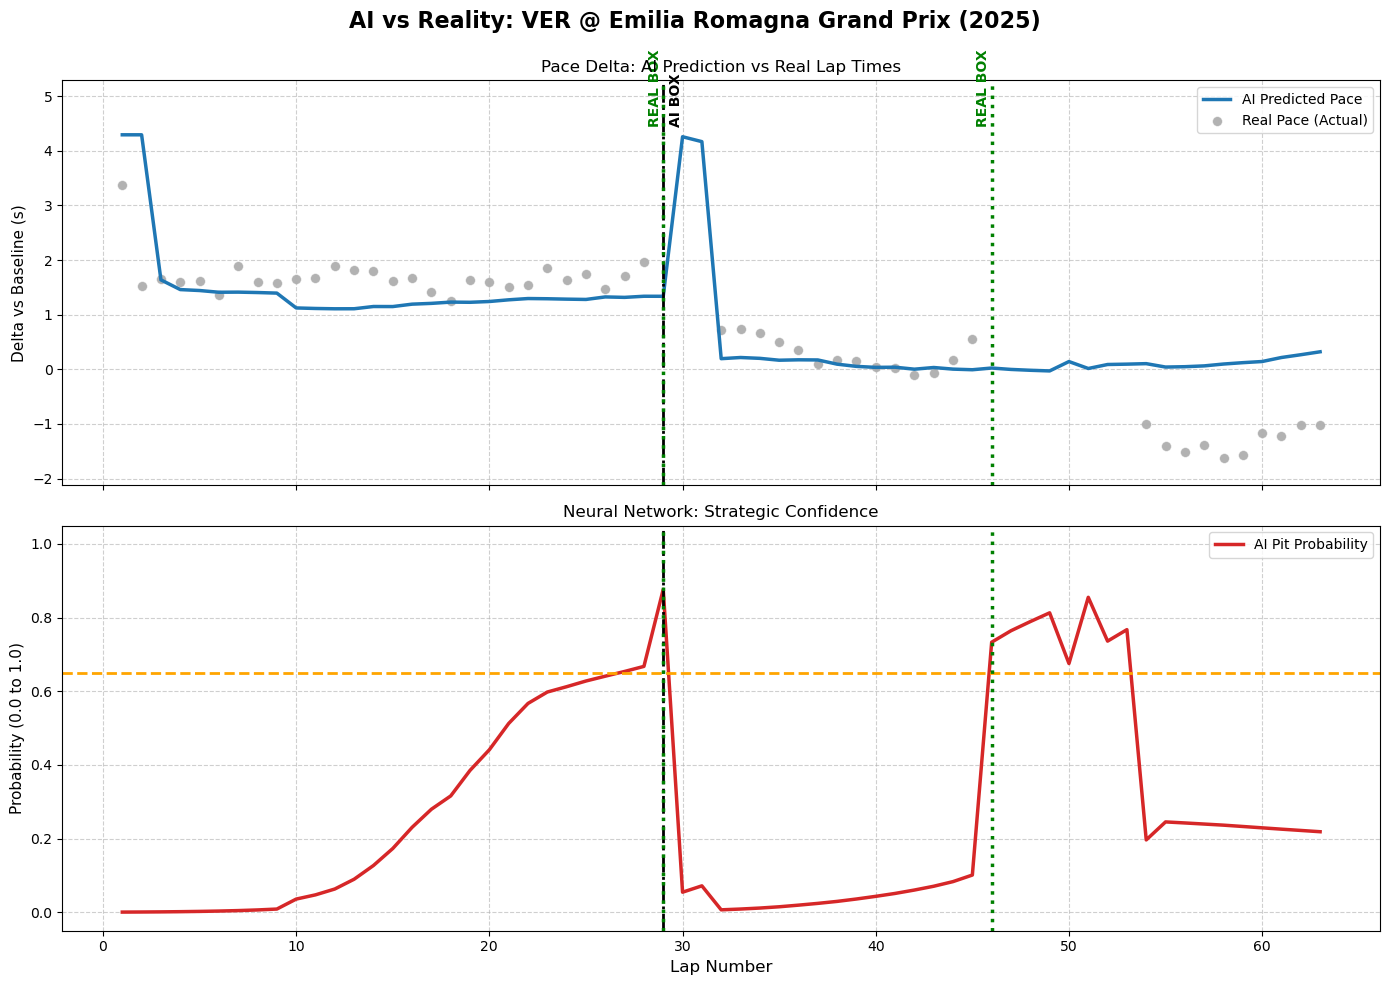

In [17]:
real_race_data = df_race[(df_race['GP'] == 'Emilia Romagna Grand Prix') & 
                         (df_race['Driver_VER'] == 1) & 
                         (df_race['Year'] == 2025)]

plot_simulation_vs_reality(
    sim_df=dynamic_sim_results, 
    real_df=real_race_data, 
    driver_code='VER', 
    gp_name='Emilia Romagna Grand Prix', 
    year=2025
) 

In [ ]:
real_race_data = df_race[(df_race['GP'] == 'Emilia Romagna Grand Prix') & 
                         (df_race['Driver_VER'] == 1) & 
                         (df_race['Year'] == 2025)]


,LapNumber,Team,Position,InPits,TrackTemp,Year,GP,RaceProgress,TyreLifeProgress,CarClose,...,Driver_RAI,Driver_RIC,Driver_RUS,Driver_SAI,Driver_SAR,Driver_STR,Driver_TSU,Driver_VER,Driver_VET,Driver_ZHO
97025,1.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.015873,0.029412,1,...,0,0,0,0,0,0,0,1,0,0
97045,2.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.031746,0.058824,1,...,0,0,0,0,0,0,0,1,0,0
97065,3.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.047619,0.088235,1,...,0,0,0,0,0,0,0,1,0,0
97085,4.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.063492,0.117647,1,...,0,0,0,0,0,0,0,1,0,0
97105,5.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.079365,0.147059,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98140,59.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.936508,0.371429,0,...,0,0,0,0,0,0,0,1,0,0
98158,60.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.952381,0.400000,0,...,0,0,0,0,0,0,0,1,0,0
98176,61.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.968254,0.428571,0,...,0,0,0,0,0,0,0,1,0,0
98194,62.0,Red Bull Racing,1.0,0,42.664,2025,Emilia Romagna Grand Prix,0.984127,0.457143,0,...,0,0,0,0,0,0,0,1,0,0
